# Caso Practico — Creatividad Digital

Escuela: Universidad de Guadalajara  
Estudiante: Mariana Fabiola Cisneros García

Este notebook presenta un análisis completo de un dataset de campañas de publicidad digital. El objetivo es explorar la estructura de los datos, construir indicadores de desempeño, analizar métricas clave de marketing yy extraer insights útiles para la toma de decisiones.

## Introducción

Las campañas de marketing digital generan grandes volúmenes de datos relacionados con impresiones, clics,onversiones, costos y resultados financieros. Analizar estas métricas permite comprender el desempeño de las campañas y optimizar las estrategias publicitarias.

En este análisis se evaluarán indicadores fundamentales como:

- CTR (Click Through Rate)
- CVR (Conversion Rate)
- CPC (Costo por clic)
- CPM (Costo por mil impresiones)
- ROI (Retorno sobre la inversión)

Además, s aplicarán técnicas de análisis estadístico, detección de valores atípicos y visualización de datos para identificar patrones relevantes en las campañas.

## Carga de datos

En esta sección se importan las librerías necesarias y se cargan ls datasets utilizados en el análisis.

In [1]:
# ========================================
# LAS LIBRERIAS AQUI PO
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

pd.set_option("display.max_columns", None)

# ==============================
# CONFIGURACION DE VISUALIZACION
# ==============================

plt.style.use("seaborn-v0_8")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.titleweight"] = "bold"

# ========================================
# CARGA DE DATOS -W-
# ========================================

df = pd.read_csv("datos/campanas_creatividad_digital.csv")

clientes = pd.read_csv("datos/clientes.csv")

print("Dataset cargado correctamente")

Dataset cargado correctamente


## Exploración del dataset

El primer paso en cualquier análisis de datos es comprender la estructura del dataset. Para ello pues se revisan:

- dimensiones del dataframe
- tipos de datos
- valores nulos
- primeras y últimas filas

In [2]:
# DIMENSIONES

df.shape

(180, 18)

In [3]:
# TIPOS DE DATOS

df.dtypes

id_campana                   str
fecha                        str
cliente                      str
plataforma                   str
formato                      str
duracion_seg               int64
objetivo                     str
pais                         str
presupuesto_usd          float64
costo_usd                float64
impresiones                int64
alcance                    int64
clicks                     int64
reproducciones_3s          int64
reproducciones_100         int64
conversiones               int64
ingresos_usd             float64
calificacion_creativa      int64
dtype: object

In [4]:
# VALORES NULOS

df.isna().sum()

id_campana               0
fecha                    0
cliente                  0
plataforma               0
formato                  0
duracion_seg             0
objetivo                 0
pais                     0
presupuesto_usd          0
costo_usd                0
impresiones              0
alcance                  0
clicks                   0
reproducciones_3s        0
reproducciones_100       0
conversiones             0
ingresos_usd             0
calificacion_creativa    0
dtype: int64

In [5]:
# COLUMNAS NUMERICAS Y CATEGORICAS

numericas = df.select_dtypes(include=np.number).columns
categoricas = df.select_dtypes(exclude=np.number).columns

numericas, categoricas

(Index(['duracion_seg', 'presupuesto_usd', 'costo_usd', 'impresiones',
        'alcance', 'clicks', 'reproducciones_3s', 'reproducciones_100',
        'conversiones', 'ingresos_usd', 'calificacion_creativa'],
       dtype='str'),
 Index(['id_campana', 'fecha', 'cliente', 'plataforma', 'formato', 'objetivo',
        'pais'],
       dtype='str'))

In [6]:
# PRIMERAS Y ULTIMAS FILAS

df.head()

,id_campana,fecha,cliente,plataforma,formato,duracion_seg,objetivo,pais,presupuesto_usd,costo_usd,impresiones,alcance,clicks,reproducciones_3s,reproducciones_100,conversiones,ingresos_usd,calificacion_creativa
0,CAMP-0001,2025-01-02,LumaAds,YouTube,Reel,30,Traffic,MX,2449.27,2356.84,319655,212076,4073,171648,26034,82,626.92,79
1,CAMP-0002,2025-01-03,FrameHouse,Facebook,Reel,25,Traffic,AR,1153.08,836.40,185919,103138,3718,88732,22749,93,678.65,93
2,CAMP-0003,2025-01-04,PixelForge,Facebook,Video Largo,60,Ventas,PE,398.93,291.12,50288,27514,488,22772,9557,24,1082.33,63
3,CAMP-0004,2025-01-05,FrameHouse,YouTube,Video Largo,90,Awareness,AR,1752.35,1304.59,279213,210519,2491,177098,29152,19,64.42,69
4,CAMP-0005,2025-01-06,NeoStudio,Instagram,Video Largo,45,Ventas,CL,703.80,640.98,140856,109020,1878,68165,39455,137,5787.29,73


In [7]:
df.tail()

,id_campana,fecha,cliente,plataforma,formato,duracion_seg,objetivo,pais,presupuesto_usd,costo_usd,impresiones,alcance,clicks,reproducciones_3s,reproducciones_100,conversiones,ingresos_usd,calificacion_creativa
175,CAMP-0176,2025-06-26,LumaAds,YouTube,Carrusel,0,Traffic,CL,1580.90,1038.68,208212,162608,2364,46551,14449,73,526.98,88
176,CAMP-0177,2025-06-27,LumaAds,Facebook,Imagen,0,Traffic,AR,1942.07,1686.23,343280,179363,5831,87296,25884,167,1424.52,78
177,CAMP-0178,2025-06-28,CromaLab,YouTube,Imagen,0,Traffic,AR,2561.05,2464.58,383086,218732,5467,95338,36307,163,1392.68,85
178,CAMP-0179,2025-06-29,CromaLab,Instagram,Story,15,Traffic,CO,2109.14,1511.14,364814,217284,8112,250048,108926,247,2059.09,92
179,CAMP-0180,2025-06-30,CromaLab,Facebook,Carrusel,0,Leads,MX,3216.03,3156.29,746485,554270,10367,193659,47865,466,10702.31,80


## Creación de indicadores derivados

A partir de las columnas originales del dataset se calculan métricas clave utilizadas en marketing digital.

Las métricas generadas son:

CTR = clicks / impresiones  
CVR = conversiones / clicks  
CPC = costo_usd / clicks  
CPM = (costo_usd / impresiones) * 1000  
ROI = (ingresos_usd - costo_usd) / costo_usd

Estas métricas pues permiten evaluar la eficiencia y rentabilidad de cada campaña.

In [8]:
# ========================================
# METRICAS DE PERFORMANCE
# ========================================

df["ctr"] = df["clicks"] / df["impresiones"]

df["cvr"] = df["conversiones"] / df["clicks"]

# ========================================
# COSTOS
# ========================================

df["cpc"] = df["costo_usd"] / df["clicks"]

df["cpm"] = (df["costo_usd"] / df["impresiones"]) * 1000

# ========================================
# ROI
# ========================================

df["roi"] = (df["ingresos_usd"] - df["costo_usd"]) / df["costo_usd"]

df[["ctr","cvr","cpc","cpm","roi"]].head()

,ctr,cvr,cpc,cpm,roi
0,0.012742,0.020133,0.578650,7.373074,-0.734000
1,0.019998,0.025013,0.224960,4.498733,-0.188606
2,0.009704,0.049180,0.596557,5.789055,2.717814
3,0.008922,0.007627,0.523721,4.672383,-0.950621
4,0.013333,0.072950,0.341310,4.550605,8.028815


## Preguntas de negocio

Una vez calculados los indicadores derivados, se utilizan filtros y agrupaciones para responder preguntas de negocio relevantes, tales como:

- identificar campañas con ROI negativo
- analizar el desempeño por plataforma
- comparar el CTR entre formatos
- identificar los países con mayores ingresos

In [9]:
mediana_costo = df["costo_usd"].median()

q1 = df[
    (df["roi"] < 0) &
    (df["costo_usd"] > mediana_costo)
]

len(q1)

36

In [10]:
q1["plataforma"].value_counts()

plataforma
Instagram    11
YouTube      10
X             5
Facebook      5
TikTok        5
Name: count, dtype: int64

In [11]:
q2 = df[
    df["plataforma"].isin(["TikTok","Instagram"])
].sort_values("roi", ascending=False).head(10)

q2

,id_campana,fecha,cliente,plataforma,formato,duracion_seg,objetivo,pais,presupuesto_usd,costo_usd,impresiones,alcance,clicks,reproducciones_3s,reproducciones_100,conversiones,ingresos_usd,calificacion_creativa,ctr,cvr,cpc,cpm,roi
150,CAMP-0151,2025-06-01,PixelForge,TikTok,Story,5,Ventas,AR,1446.89,1432.64,483778,379185,12678,311799,64308,944,49322.31,76,0.026206,0.074460,0.113002,2.961358,33.427567
54,CAMP-0055,2025-02-25,PixelForge,TikTok,Story,10,Ventas,AR,2158.86,1952.28,627880,466309,16608,437914,115208,1222,60119.39,72,0.026451,0.073579,0.117551,3.109320,29.794451
158,CAMP-0159,2025-06-09,NeoStudio,TikTok,Reel,10,Ventas,CO,3472.48,2900.57,883683,759848,28136,524059,134825,1656,84100.28,77,0.031839,0.058857,0.103091,3.282365,27.994398
100,CAMP-0101,2025-04-12,PixelForge,TikTok,Carrusel,0,Ventas,AR,3117.30,2218.04,724207,622121,15486,195432,85354,1198,62497.38,82,0.021383,0.077360,0.143229,3.062715,27.176850
66,CAMP-0067,2025-03-09,NeoStudio,TikTok,Reel,15,Ventas,CO,2782.13,1882.76,537624,376554,11620,258009,144902,962,46784.54,76,0.021614,0.082788,0.162028,3.502001,23.848913
19,CAMP-0020,2025-01-21,CromaLab,TikTok,Reel,10,Ventas,MX,1098.95,937.63,314713,167744,7403,201724,66975,420,22218.58,62,0.023523,0.056734,0.126655,2.979318,22.696533
157,CAMP-0158,2025-06-08,NeoStudio,TikTok,Video Largo,90,Ventas,MX,1059.73,1057.54,288436,151901,5036,152145,73612,441,19772.16,84,0.017460,0.087569,0.209996,3.666463,17.696371
31,CAMP-0032,2025-02-02,LumaAds,TikTok,Story,10,Ventas,CL,1744.15,1227.09,270189,188428,6468,186500,89677,465,21556.20,70,0.023939,0.071892,0.189717,4.541599,16.566927
138,CAMP-0139,2025-05-20,LumaAds,TikTok,Reel,20,Ventas,MX,1739.96,1535.43,378062,204732,9729,192421,44875,601,26374.02,75,0.025734,0.061774,0.157820,4.061318,16.176960
22,CAMP-0023,2025-01-24,FrameHouse,TikTok,Imagen,0,Ventas,CO,1925.22,1677.89,407613,325382,8648,63564,10786,706,28810.28,79,0.021216,0.081637,0.194021,4.116380,16.170542


In [12]:
q3 = df.groupby("formato")["ctr"].mean().sort_values(ascending=False)

q3

formato
Reel           0.020697
Story          0.018089
Carrusel       0.016975
Imagen         0.013379
Video Largo    0.013289
Name: ctr, dtype: float64

In [13]:
q4 = df.groupby("pais")["ingresos_usd"].sum().sort_values(ascending=False)

q4

pais
CO    403762.10
AR    269396.00
MX    210840.92
CL    206504.35
PE    152053.80
Name: ingresos_usd, dtype: float64

## Estadística descriptiva - Tendencia central

La tendencia central permite identificar el valor típico de una variable dentro del dataset.

Se calcularán:

- media
- mediana
- moda (cuando aplica)

Estas métricas permiten entender el comportamiento promedio de las campañas.

In [14]:
columnas_metricas = [
"costo_usd","impresiones","clicks",
"conversiones","ingresos_usd",
"ctr","cvr","cpc","cpm","roi"
]

tendencia_central = pd.DataFrame({

"media": df[columnas_metricas].mean(),

"mediana": df[columnas_metricas].median()

})

tendencia_central

,media,mediana
costo_usd,1552.059222,1411.905000
impresiones,320647.616667,307169.500000
clicks,5601.138889,4433.500000
conversiones,221.577778,142.500000
ingresos_usd,6903.095389,1864.945000
ctr,0.017121,0.016318
cvr,0.040058,0.038661
cpc,0.341340,0.291472
cpm,5.040922,4.835617
roi,3.498346,0.646721


## Estadística descriptiva - Dispersión

La dispersión mide q tan alejados están los datos respecto al valor promedio.

Las métricas calculadas incluyen:

- desviación estándar
- varianza
- rango
- rango intercuartílico (IQR)

Este análisis permite identificar qué métricas presentan mayor variabilidad entre campañas.

In [15]:
dispersion = pd.DataFrame({

"std": df[columnas_metricas].std(),

"var": df[columnas_metricas].var(),

"rango": df[columnas_metricas].max() - df[columnas_metricas].min(),

"iqr": df[columnas_metricas].quantile(.75) - df[columnas_metricas].quantile(.25)

})

dispersion

,std,var,rango,iqr
costo_usd,876.228637,7.677766e+05,5814.060000,1232.820000
impresiones,182419.998948,3.327706e+10,867503.000000,237395.000000
clicks,4193.217039,1.758307e+07,27648.000000,4696.250000
conversiones,239.421532,5.732267e+04,1648.000000,226.250000
ingresos_usd,11625.027287,1.351413e+08,84074.370000,8280.960000
ctr,0.005161,2.663320e-05,0.027800,0.006665
cvr,0.024993,6.246660e-04,0.084922,0.040390
cpc,0.212825,4.529469e-02,1.873467,0.183360
cpm,1.330021,1.768956e+00,9.126577,1.624970
roi,6.321335,3.995928e+01,34.378188,5.685102


## Detección de valores atípicos

Los outliers son observaciones que se alejan significativamente del comportamiento general de los datos.
En este análisis pues se utilizará el método del rango intercuartílico (IQR) para detectar valores atípicos en:

- CTR
- ROI

Identificar estos valores permitiria entender campañas excepcionalmente exitosas o con desempeño inusualmente bajo.

In [16]:
Q1 = df["ctr"].quantile(.25)
Q3 = df["ctr"].quantile(.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_ctr = df[
(df["ctr"] < lim_inf) |
(df["ctr"] > lim_sup)
]

len(outliers_ctr)

3

In [17]:
Q1 = df["roi"].quantile(.25)
Q3 = df["roi"].quantile(.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_roi = df[
(df["roi"] < lim_inf) |
(df["roi"] > lim_sup)
]

len(outliers_roi)

12

## Análisis visual de las campañas

Las visualizaciones permiten identificar patrones en el desempeño de las campañas que no siempre son evidentes mediante estadísticas descriptivas.

A continuación se presentan diferentes gráficos que exploran la distribución del ROI, el comportamiento del CTR según plataforma y formato, y la evolución de los ingresos en el tiempo.

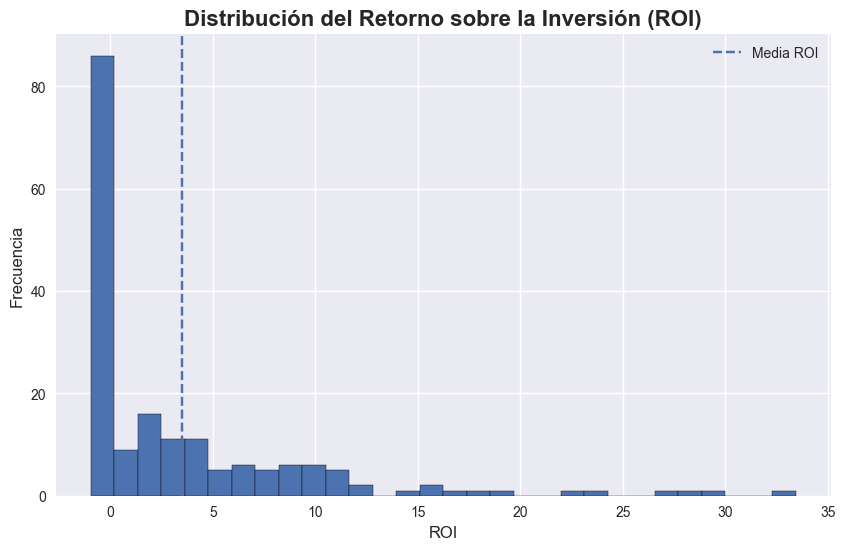

In [18]:
plt.figure()

plt.hist(df["roi"], bins=30, edgecolor="black")

plt.axvline(df["roi"].mean(), linestyle="--", label="Media ROI")

plt.title("Distribución del Retorno sobre la Inversión (ROI)")
plt.xlabel("ROI")
plt.ylabel("Frecuencia")

plt.legend()

plt.show()

La distribución del ROI muestra que la mayoría de las campañas generan retornos positivos, aunque existen algunos valores extremos que indican campañas excepcionalmente exitosas o con bajo desempeño.

<Figure size 1000x600 with 0 Axes>

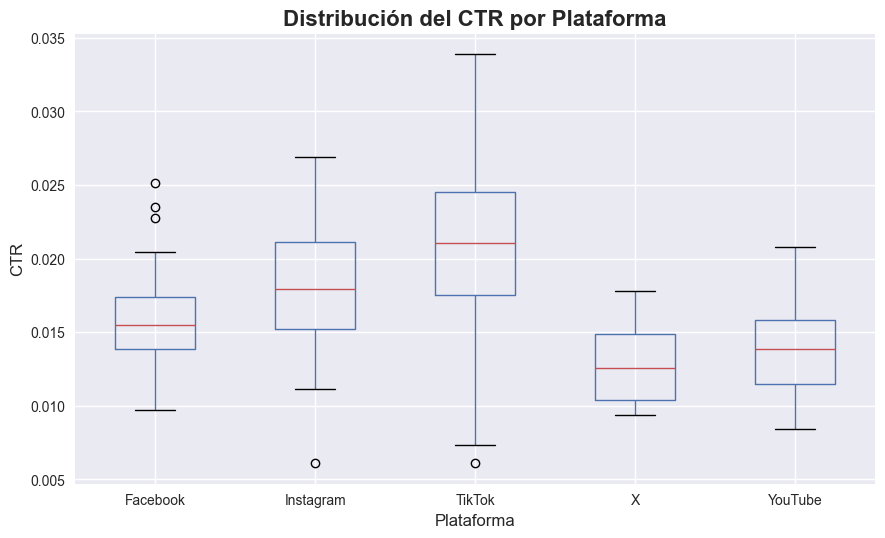

In [19]:
plt.figure()

df.boxplot(column="ctr", by="plataforma")

plt.title("Distribución del CTR por Plataforma")
plt.suptitle("")
plt.xlabel("Plataforma")
plt.ylabel("CTR")

plt.show()

El boxplot permite comparar la distribución del CTR entre plataformas y pues aca se observan diferencias en la mediana y presencia de valores atípicos en algunas plataformas.

In [20]:
ctr_formato = df.groupby("formato")["ctr"].mean().sort_values(ascending=False)

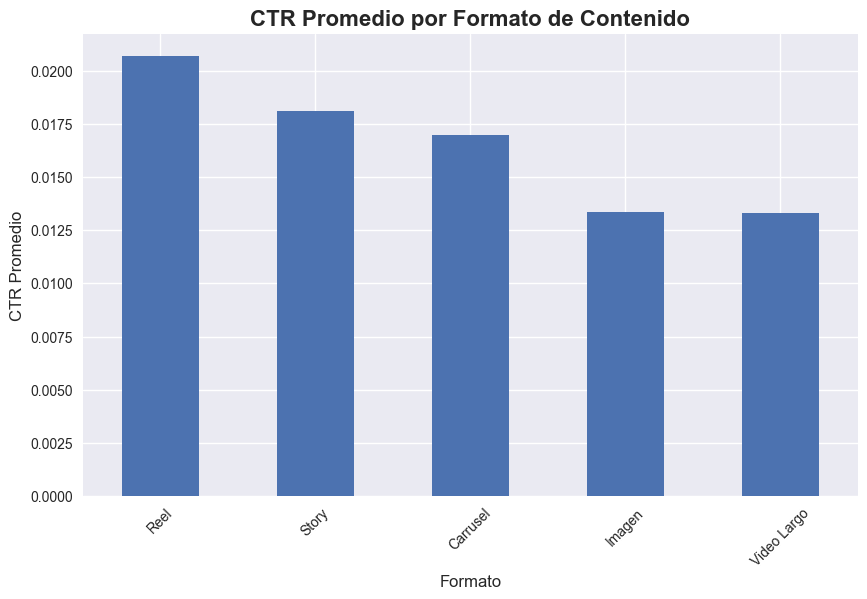

In [21]:
plt.figure()

ctr_formato.plot(kind="bar")

plt.title("CTR Promedio por Formato de Contenido")
plt.xlabel("Formato")
plt.ylabel("CTR Promedio")

plt.xticks(rotation=45)

plt.show()

Los formatos de video corto presentan mayores tasas d interacción en comparación con formatos estáticos, lo cual sugiere una mayor efectividad para captar la atención del usuario o de quien loeste usando.

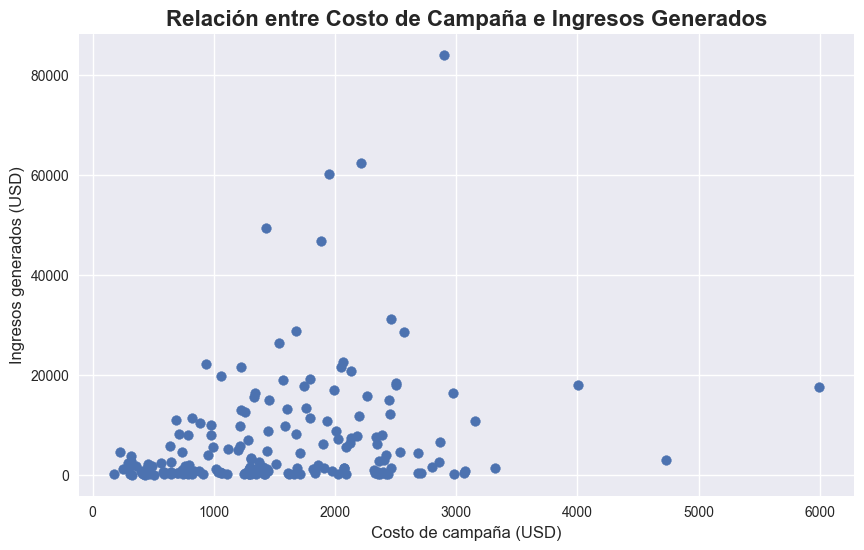

In [22]:
plt.figure()

plt.scatter(df["costo_usd"], df["ingresos_usd"])

plt.title("Relación entre Costo de Campaña e Ingresos Generados")
plt.xlabel("Costo de campaña (USD)")
plt.ylabel("Ingresos generados (USD)")

plt.grid(True)

plt.show()

Existe una relación positiva entre el costo de campaña y los ingresos generados, aunque pues con variabilidad significativa, lo cual sugiere que una mayor inversión no garantiza necesariamente mejores resultados.

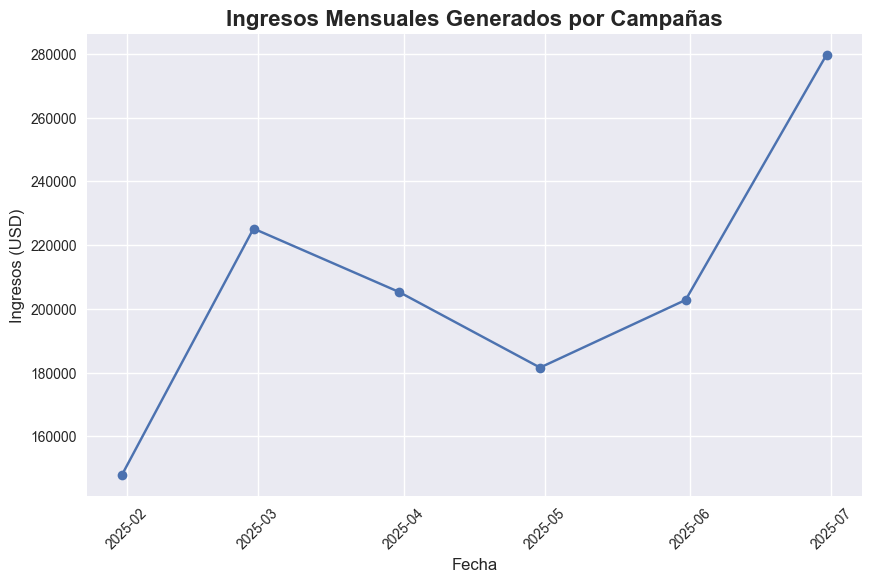

In [23]:
df["fecha"] = pd.to_datetime(df["fecha"])

ingresos_mes = df.resample("ME", on="fecha")["ingresos_usd"].sum()

plt.figure()

plt.plot(ingresos_mes.index, ingresos_mes.values, marker="o")

plt.title("Ingresos Mensuales Generados por Campañas")
plt.xlabel("Fecha")
plt.ylabel("Ingresos (USD)")

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

## Integración de datasets

En muchos proyectos reales de análisis de datos la información se encuentra distribuida en múltiples tablas.

En esta sección pues se integrará el dataset de campañas con una tabla adicional de clientes utilizando operaciones de merge:

- left merge
- inner merge
- outer merge

Esto permitirá enriquecer el análisis con información contextual sobre los clientes.

In [24]:
m1 = pd.merge(df, clientes, on="cliente", how="left")

m2 = pd.merge(df, clientes, on="cliente", how="inner")

m3 = pd.merge(df, clientes, on="cliente", how="outer")

In [25]:
pm1 = m1.groupby("industria")["roi"].mean().sort_values(ascending=False)

pm1

industria
Retail                 5.081178
Entretenimiento        4.343735
Alimentos y Bebidas    3.489999
Tecnologia             3.115912
Moda y Belleza         2.299934
Name: roi, dtype: float64

In [26]:
pm2 = m1.groupby("nivel_contrato")["ctr"].mean().sort_values(ascending=False)

pm2

nivel_contrato
Enterprise    0.017570
Premium       0.017384
Basico        0.015769
Name: ctr, dtype: float64

## Análisis posterior al merge

Una vez integrados los datasets se analizan nuevas relaciones entre variables, como:

- desempeño de campañas por industria
- CTR promedio según nivel de contrato
- desempeño de campañas de empresas grandes

In [27]:
grandes = m1[m1["tamano"] == "Grande"]

campanas_grandes = len(grandes)

positivas = len(grandes[grandes["roi"] > 0])

porcentaje = positivas / campanas_grandes * 100

campanas_grandes, positivas, porcentaje

(58, 37, 63.793103448275865)

## Insights automáticos del dataset

En esta sección se generan algunos hallazgos automáticos a partir de los datos utilizando operaciones de agregación y ordenamiento. Esto permite identificar rápidamente patrones relevantes en el desempeño de las campañas.

In [28]:
roi_plataforma = df.groupby("plataforma")["roi"].mean().sort_values(ascending=False)

roi_plataforma

plataforma
TikTok       6.672855
Instagram    3.146111
Facebook     2.167606
YouTube      1.974836
X            1.769305
Name: roi, dtype: float64

In [29]:
mejor_plataforma = roi_plataforma.idxmax()
valor_roi = roi_plataforma.max()

print("La plataforma con mayor ROI promedio es:", mejor_plataforma)
print("ROI promedio:", round(valor_roi,3))

La plataforma con mayor ROI promedio es: TikTok
ROI promedio: 6.673


El análisis muestra qué plataforma genera el mayor retorno promedio sobre la inversión publicitaria.

In [30]:
top_roi = df.sort_values("roi", ascending=False).head(1)

top_roi[["cliente","plataforma","formato","roi","ingresos_usd"]]

,cliente,plataforma,formato,roi,ingresos_usd
150,PixelForge,TikTok,Story,33.427567,49322.31


Esta campaña representa el caso de mayor retorno sobre inversión dentro del dataset analizado.

In [31]:
ctr_formato = df.groupby("formato")["ctr"].mean().sort_values(ascending=False)

ctr_formato

formato
Reel           0.020697
Story          0.018089
Carrusel       0.016975
Imagen         0.013379
Video Largo    0.013289
Name: ctr, dtype: float64

In [32]:
mejor_formato = ctr_formato.idxmax()
valor_ctr = ctr_formato.max()

print("El formato con mayor CTR promedio es:", mejor_formato)
print("CTR promedio:", round(valor_ctr,4))

El formato con mayor CTR promedio es: Reel
CTR promedio: 0.0207


Los formatos con mayor CTR suelen ser aquellos con contenido dinámico o visualmente atractivo.

In [33]:
ingresos_pais = df.groupby("pais")["ingresos_usd"].sum().sort_values(ascending=False)

ingresos_pais

pais
CO    403762.10
AR    269396.00
MX    210840.92
CL    206504.35
PE    152053.80
Name: ingresos_usd, dtype: float64

In [34]:
top_pais = ingresos_pais.idxmax()
top_ingreso = ingresos_pais.max()

print("El país con mayor ingreso total generado es:", top_pais)
print("Ingresos totales:", round(top_ingreso,2))

El país con mayor ingreso total generado es: CO
Ingresos totales: 403762.1


Este resultado permite identificar los mercados geográficos con mayor impacto económico en las campañas analizadas.

## Conclusiones

El análisis de las campañas de creatividad digital ayuda a  identificar patrones relevantes en el desempeño publicitario.

Se observó que el formato del contenido y la plataforma utilizada influyen significativamente en métricas como CTR y ROI. Asimismo, la integración de información de clientes permitió analizar el rendimiento de campañas según industria, tamaño de empresa y nivel de contrato.

Este tipo de análisis es fundamental para optimizar estrategias de marketing digital y mejorar la asignación de recursos publicitarios.